### Imports and paths

In [ ]:
import sys
from pathlib import Path
from typing import Dict, Any, Tuple

import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import time

from datasets import load_dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

ROOT = Path.cwd().resolve().parent  

if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from project_paths import get_paths

paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("DATA_DIR:", DATA_DIR)
print("CKPT_DIR:", CKPT_DIR)

MODEL_SPECS = {
    
    "teacher_base":{
        "display_name": "Teacher Base",
        "ckpt_path": "google-bert/bert-base-uncased",
        "threshold": 0.42,
        "bar_color": "#b96329",   
        "cm_cmap": "Oranges",    
        "n_params": 109_482_240, 
    },
    "teacher_ft": {
        "display_name": "Teacher Fine-Tuned",
        "ckpt_path": CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000",   
        "threshold": 0.52,
        "bar_color": "#c0392b",   
        "cm_cmap": "Blues",   
        "n_params": 109_482_240,    
    },
    "student_base":{
        "display_name": "Student Base",
        "ckpt_path": "huawei-noah/TinyBERT_General_4L_312D",  
        "threshold": 0.01,
        "bar_color": "#27ae60",   
        "cm_cmap": "Greens",    
        "n_params": 14_500_000,   
    },
    "student_kd": {
        "display_name": "Student Distilled",
        "ckpt_path": CKPT_DIR / "tinybert_phase2" / "checkpoint-13000",  
        "threshold": 0.50,
        "bar_color": "#1f4e79", 
        "cm_cmap": "Reds",  
        "n_params": 14_500_000,   
    },
}



for k, v in MODEL_SPECS.items():
    print(f"{k}:")
    print("  path      =", v["ckpt_path"])
    print("  threshold =", v["threshold"])

c:\Users\cola0\anaconda3\envs\nlp-project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
DATA_DIR: C:\Users\cola0\Desktop\nlp.project-colangelo-2526\data\processed
CKPT_DIR: C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints
teacher_ft:
  path      = C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\bert_teacher_finetuned\checkpoint-18000
  threshold = 0.52
student_base:
  path      = huawei-noah/TinyBERT_General_4L_312D
  threshold = 0.01
student_kd:
  path      = C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\tinybert_phase2\checkpoint-13000
  threshold = 0.5


### Loading test set

In [2]:
test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]

if "labels" not in test_ds.column_names and "label" in test_ds.column_names:
    test_ds = test_ds.rename_column("label", "labels")

required_cols = {"input_ids", "attention_mask", "labels"}
missing_cols = required_cols - set(test_ds.column_names)
if missing_cols:
    raise ValueError(f"Mancano colonne nel test set: {missing_cols}")

print("Test size:", len(test_ds))
print("Columns:", test_ds.column_names)
print("Sample keys:", test_ds[0].keys())

Test size: 9925
Columns: ['review_id', 'movie_id', 'text', 'labels', 'input_ids', 'attention_mask', 'token_type_ids']
Sample keys: dict_keys(['review_id', 'movie_id', 'text', 'labels', 'input_ids', 'attention_mask', 'token_type_ids'])


In [ ]:
@torch.no_grad() 
def measure_inference_time(trainer: Trainer, ds, warmup_batches: int = 5) -> Dict[str, float]:
    model = trainer.model
    model.eval() 
    dataloader = trainer.get_eval_dataloader(ds)

    for i, batch in enumerate(dataloader):
        if i >= warmup_batches:
            break
        batch = {k: v.to(device) for k, v in batch.items()}
        _ = model(**batch)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    n_samples = 0
    for batch in dataloader:
        bs = batch["input_ids"].shape[0]
        n_samples += bs
        batch = {k: v.to(device) for k, v in batch.items()}
        _ = model(**batch)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end = time.perf_counter()
    total_s = end - start

    return {
        "total_seconds": float(total_s),
        "ms_per_sample": float((total_s / n_samples) * 1000.0),
        "samples_per_second": float(n_samples / total_s),
        "n_samples": int(n_samples),
    }

def make_infer_trainer(model_path: Path, per_device_eval_batch_size: int = 32) -> Trainer:
    tokenizer = AutoTokenizer.from_pretrained(str(model_path), use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(model_path)).to(device)
    model.eval()

    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    args = TrainingArguments(
        output_dir=str(CKPT_DIR / "_tmp_eval_graphs"),
        per_device_eval_batch_size=per_device_eval_batch_size,
        dataloader_num_workers=2,
        report_to="none",
        fp16=False,   
    )

    trainer = Trainer(
        model=model,
        args=args,
        data_collator=collator,
        tokenizer=tokenizer,
    )
    return trainer


def logits_to_positive_probs(predictions: np.ndarray) -> np.ndarray:
    logits = torch.tensor(predictions)

    if logits.ndim == 2 and logits.shape[1] == 2:
        probs = torch.softmax(logits, dim=-1)[:, 1]
    elif logits.ndim == 1:
        probs = torch.sigmoid(logits)
    elif logits.ndim == 2 and logits.shape[1] == 1:
        probs = torch.sigmoid(logits[:, 0])
    else:
        raise ValueError(f"Shape logits non gestita: {tuple(logits.shape)}")

    return probs.cpu().numpy()


def predict_probs_and_labels(trainer: Trainer, ds) -> Tuple[np.ndarray, np.ndarray]:
    pred_out = trainer.predict(ds)
    probs = logits_to_positive_probs(pred_out.predictions)
    y_true = pred_out.label_ids.astype(int)
    return y_true, probs


def compute_metrics_from_probs(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> Dict[str, float]:
    y_pred = (probs >= threshold).astype(int)

    metrics = {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "F1": float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "Precision": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "ROC-AUC": float(roc_auc_score(y_true, probs)),
        "PR-AUC": float(average_precision_score(y_true, probs)),
        "Pred Positive Rate": float(y_pred.mean()),
    }
    return metrics


def compute_confusion_matrix(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> np.ndarray:
    y_pred = (probs >= threshold).astype(int)
    return confusion_matrix(y_true, y_pred, labels=[0, 1])


def row_normalize_cm(cm: np.ndarray) -> np.ndarray:
    cm = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    return cm / row_sums


def evaluate_model_on_test(spec: Dict[str, Any], test_ds, batch_size: int = 32, measure_time: bool = True) -> Dict[str, Any]:
    trainer = make_infer_trainer(spec["ckpt_path"], per_device_eval_batch_size=batch_size)
    y_true, probs = predict_probs_and_labels(trainer, test_ds)

    threshold = spec["threshold"]
    metrics = compute_metrics_from_probs(y_true, probs, threshold)
    cm = compute_confusion_matrix(y_true, probs, threshold)

    timing = None 
    if measure_time:
        timing = measure_inference_time(trainer, test_ds, warmup_batches=5)

    return {
        "display_name": spec["display_name"],
        "threshold": threshold,
        "y_true": y_true,
        "probs": probs,
        "metrics": metrics,
        "cm": cm,
        "n_params": spec.get("n_params", None),
        "timing": timing,
    }


def build_metrics_dataframe(results_dict: Dict[str, Dict[str, Any]], metrics_order=None) -> pd.DataFrame:
    if metrics_order is None:
        metrics_order = ["Accuracy", "F1", "Precision", "Recall", "ROC-AUC", "PR-AUC"]

    rows = []
    for model_key, res in results_dict.items():
        for metric_name in metrics_order:
            rows.append({
                "ModelKey": model_key,
                "Model": res["display_name"],
                "Metric": metric_name,
                "Value": res["metrics"][metric_name],
            })

    df = pd.DataFrame(rows)
    df["Metric"] = pd.Categorical(df["Metric"], categories=metrics_order, ordered=True)
    return df

In [ ]:
fontsize =11

def plot_confusion_matrices(
    results_dict: Dict[str, Dict[str, Any]],
    specs_dict: Dict[str, Dict[str, Any]],
    model_keys=("teacher_ft", "student_kd"),
    label_names=("No Spoiler", "Spoiler"),
    normalized=False,
    figsize=(9, 4.6),
    annot_fontsize=fontsize,
):
    sns.set_theme(style="white", context="notebook")

    # estrai cm
    cms = []
    for k in model_keys:
        cm = results_dict[k]["cm"]
        if normalized:
            cm = row_normalize_cm(cm)
        cms.append(cm)

    vmax = max(cm.max() for cm in cms)
    vmin = 0.0

    fig, axes = plt.subplots(1, len(model_keys), figsize=figsize)
    if len(model_keys) == 1:
        axes = [axes]

    for ax, k, cm in zip(axes, model_keys, cms):
        spec = specs_dict[k]
        res = results_dict[k]

        sns.heatmap(
            cm,
            annot=True,
            fmt=".2%" if normalized else "d",
            cmap=spec["cm_cmap"],
            cbar=False,
            square=True,            # celle quadrate
            linewidths=0.6,
            linecolor="white",
            vmin=vmin,
            vmax=vmax,
            xticklabels=label_names,
            yticklabels=label_names,
            annot_kws={"size": annot_fontsize},
            ax=ax
        )

        title_suffix = "Normalized" if normalized else "Test set"
        ax.set_title(
            f"{res['display_name']}",
            fontsize=12
        )
        ax.set_xlabel("Predicted label", fontsize=fontsize)
        ax.set_ylabel("True label", fontsize=fontsize)
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='y', rotation=90)
        ax.margins(0.05) 

    plt.tight_layout(pad=0.8, w_pad=0.8)
    return fig, axes

In [ ]:
fontsize = 9

def plot_metrics_barchart(
    df_metrics: pd.DataFrame,
    specs_dict: Dict[str, Dict[str, Any]],
    model_keys=("teacher_ft", "student_kd"),
    figsize=(8, 6),
    y_lim=(0.0, 1.0),
    title="Teacher vs Student — Main Performance Metrics (Test Set)",
    show_values=True,
    fontsize = fontsize
):
    sns.set_theme(style="whitegrid", context="notebook")

    df_plot = df_metrics[df_metrics["ModelKey"].isin(model_keys)].copy()

    hue_order = list(model_keys)
    display_name_map = {k: specs_dict[k]["display_name"] for k in model_keys}
    color_map = {display_name_map[k]: specs_dict[k]["bar_color"] for k in model_keys}

    ordered_model_names = [display_name_map[k] for k in hue_order]
    df_plot["Model"] = pd.Categorical(df_plot["Model"], categories=ordered_model_names, ordered=True)

    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=df_plot,
        x="Metric",
        y="Value",
        hue="Model",
        hue_order=ordered_model_names,
        palette=color_map,
        ax=ax,
        width=0.9,
    )

    ax.set_ylim(*y_lim)
    ax.set_title(title, fontweight="bold", fontsize=fontsize)
    ax.set_xlabel("", fontweight="bold", fontsize=fontsize)
    ax.set_ylabel("Score", fontweight="bold", fontsize=fontsize)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
        label.set_fontsize(fontsize)


    if show_values:
        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", padding=3, fontsize=fontsize,  fontweight="bold")     

    ax.legend(title="", loc="upper right", frameon=True)
    for text in ax.legend().get_texts():
        text.set_fontweight("bold")
        text.set_fontsize(fontsize)

    plt.tight_layout()

    return fig, ax

In [ ]:
results = {}

for model_key in ["student_base","teacher_ft", "student_kd"]:
    print(f"\n=== Evaluating: {model_key} ({MODEL_SPECS[model_key]['display_name']}) ===")
    res = evaluate_model_on_test(MODEL_SPECS[model_key], test_ds, batch_size=32)
    results[model_key] = res

    print("Threshold:", res["threshold"])
    print("Pred positive rate:", round(res["metrics"]["Pred Positive Rate"], 6))
    print("Metrics:")
    for mk, mv in res["metrics"].items():
        if mk != "Pred Positive Rate":
            print(f"  {mk}: {mv:.6f}")
    print("Confusion matrix:\n", res["cm"])


=== Evaluating: student_base (Student Base) ===


c:\Users\cola0\anaconda3\envs\nlp-project\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\cola0\.cache\huggingface\hub\models--huawei-noah--TinyBERT_General_4L_312D. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling b

Threshold: 0.01
Pred positive rate: 1.0
Metrics:
  Accuracy: 0.262771
  F1: 0.416181
  Precision: 0.262771
  Recall: 1.000000
  ROC-AUC: 0.567981
  PR-AUC: 0.317868
Confusion matrix:
 [[   0 7317]
 [   0 2608]]

=== Evaluating: teacher_ft (Teacher Fine-Tuned) ===


C:\Users\cola0\AppData\Local\Temp\ipykernel_18920\349597760.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


KeyboardInterrupt: 

In [ ]:
metrics_order = ["Accuracy", "F1", "Precision", "Recall", "ROC-AUC", "PR-AUC"]
df_metrics = build_metrics_dataframe(results, metrics_order=metrics_order)

df_metrics

,ModelKey,Model,Metric,Value
0,teacher_base,Teacher Base,Accuracy,0.259603
1,teacher_base,Teacher Base,F1,0.412139
2,teacher_base,Teacher Base,Precision,0.259572
3,teacher_base,Teacher Base,Recall,0.999754
4,teacher_base,Teacher Base,ROC-AUC,0.484980
5,teacher_base,Teacher Base,PR-AUC,0.254034
6,student_base,Student Base,Accuracy,0.259603
7,student_base,Student Base,F1,0.412198
8,student_base,Student Base,Precision,0.259603
9,student_base,Student Base,Recall,1.000000


In [ ]:
FIG_DIR = paths.root / "report"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Plot 1: Confusion Matrix for both the models

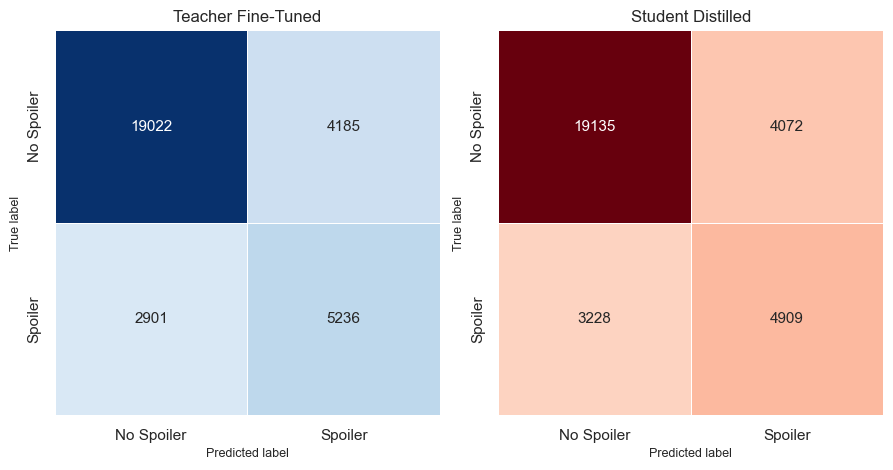

In [ ]:
fig_cm_abs, axes_cm_abs = plot_confusion_matrices(
    results_dict=results,
    specs_dict=MODEL_SPECS,
    model_keys=("teacher_ft", "student_kd"),
    normalized=False,
    figsize=(9, 4.6),
    annot_fontsize=11,
)
plt.show()

fig_cm_abs.savefig(FIG_DIR / "confusion_matrices_absolute.png", dpi=600)

## Plot 2: Bar char with all evaluation metrics for both the models

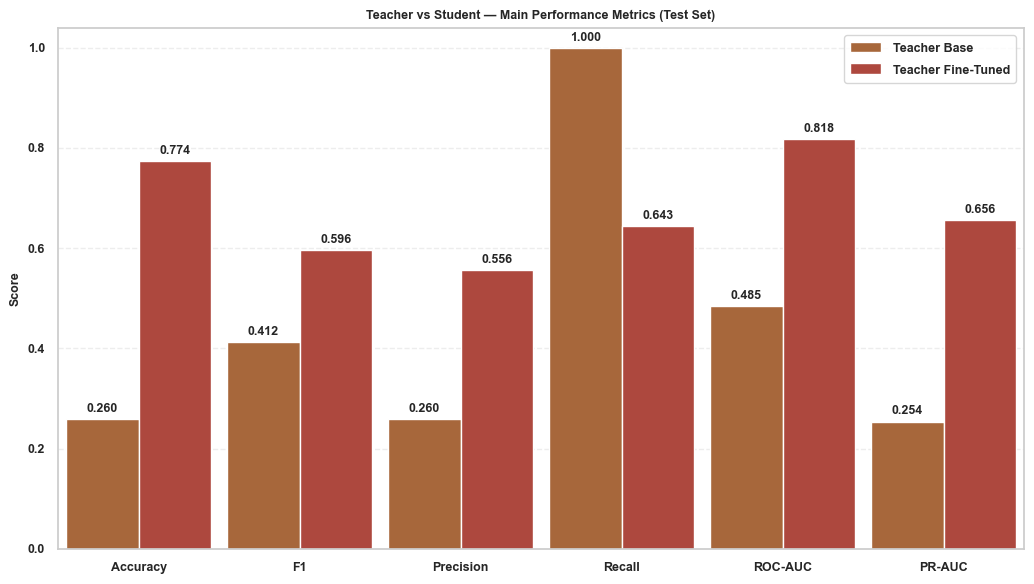

In [ ]:
fig_bar_full, ax_bar_full = plot_metrics_barchart(
    df_metrics=df_metrics,
    specs_dict=MODEL_SPECS,
    model_keys=("teacher_ft", "student_base", "student_kd"),
    figsize=(10.5, 6),
    y_lim=(0.0, 1.04),
    title="Teacher vs Student — Main Performance Metrics (Test Set)",
    show_values=True,
    fontsize = 9,
)
plt.show()

fig_bar_full.savefig(FIG_DIR / "metrics_barchart.png", dpi=1200)

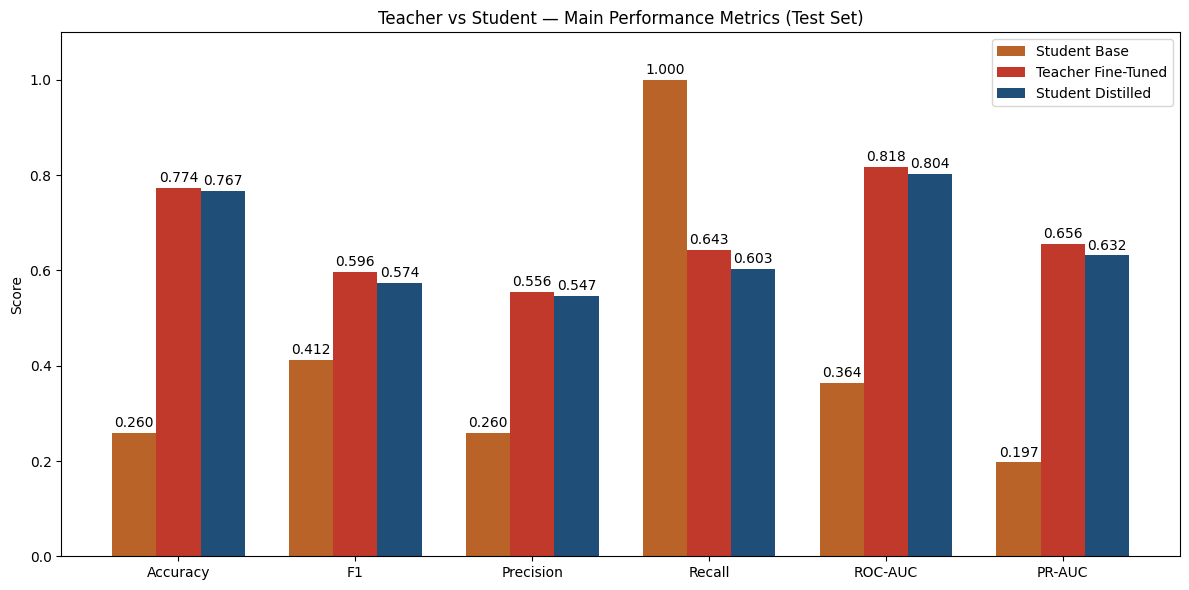

<Figure size 640x480 with 0 Axes>

In [11]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "F1", "Precision", "Recall", "ROC-AUC", "PR-AUC"]

student_base =      [0.259603, 0.412198, 0.259603, 1.000000, 0.364079, 0.197066]
teacher_ft =        [0.773928, 0.596423, 0.555780, 0.643480, 0.818076, 0.656376]
student_distilled = [0.767101, 0.573548, 0.546598, 0.603294, 0.803560, 0.631799]

x = np.arange(len(metrics))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w, student_base, w, label="Student Base", color="#b96329")  
b2 = ax.bar(x, teacher_ft, w, label="Teacher Fine-Tuned", color="#c0392b")
b3 = ax.bar(x + w, student_distilled, w, label="Student Distilled", color="#1f4e79")

ax.set_ylabel("Score")
ax.set_title("Teacher vs Student — Main Performance Metrics (Test Set)")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=10)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=10)
ax.bar_label(b3, fmt="%.3f", padding=2, fontsize=10)

plt.tight_layout()
plt.savefig("performance_metrics.png", dpi=600)
plt.show()
plt.savefig('metrics.png')

## Plot 3: Scatter plots to evaluate inference time and memory usage of both models

In [ ]:
def build_efficiency_dataframe(results_dict: Dict[str, Dict[str, Any]],model_keys) -> pd.DataFrame:
    rows = []
    for k in model_keys: 
        res = results_dict[k]
        rows.append({
            "ModelKey": k,
            "Model": res["display_name"],
            "PR-AUC": res["metrics"]["PR-AUC"],
            "ROC-AUC": res["metrics"]["ROC-AUC"],
            "F1": res["metrics"]["F1"],
            "ms_per_sample": res["timing"]["ms_per_sample"] if res["timing"] else np.nan,
            "samples_per_second": res["timing"]["samples_per_second"] if res["timing"] else np.nan,
            "n_params": res.get("n_params", np.nan),
            "color": MODEL_SPECS[k]["bar_color"],
        })
    return pd.DataFrame(rows) 

import matplotlib.lines as mlines

def plot_scatter_prauc_vs_time(df_eff: pd.DataFrame, title="PR-AUC vs Inference Time", fontsize=11):
    sns.set_theme(style="whitegrid", context="notebook")
    fig, ax = plt.subplots(figsize=(9, 6))

    legend_handles = []

    for _, r in df_eff.iterrows():
        x = r["ms_per_sample"]
        y = r["PR-AUC"]
        c = r["color"]
        label = r["Model"]

        ax.scatter([x], [y], s=140, color=c, edgecolor="white", linewidth=1.2, zorder=3)

        legend_handles.append(
            mlines.Line2D([], [], color=c, marker='o', linestyle='None',
                          markersize=9, label=label)
        )

    ax.relim()
    ax.autoscale_view()
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)

    line_width = 0.8
    for _, r in df_eff.iterrows():
        x = r["ms_per_sample"]
        y = r["PR-AUC"]
        c = r["color"]
        
        ax.vlines(x, ymin=y0, ymax=y, colors=c, linestyles="--", linewidth=line_width, alpha=0.9, zorder=2)
        ax.hlines(y, xmin=x0, xmax=x, colors=c, linestyles="--", linewidth=line_width, alpha=0.9, zorder=2)

    ax.set_title(title, fontsize=fontsize, fontweight='bold')
    ax.set_xlabel("Inference time (ms per sample) — Lower is better", fontsize=fontsize, fontweight='bold')
    ax.set_ylabel("PR-AUC — Higher is better", fontsize=fontsize, fontweight='bold')
    ax.grid(True, linestyle="--", alpha=0.35)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(fontsize)
        label.set_fontweight('bold')

    legend = ax.legend(
        handles=legend_handles, 
        title="", 
        bbox_to_anchor=(1.05, 1), 
        loc="upper left", 
        frameon=True
    )
    for text in legend.get_texts():
        text.set_fontsize(fontsize)
        text.set_fontweight('bold')

    plt.tight_layout()
    return fig, ax
    


In [ ]:

def plot_scatter_prauc_vs_params(df_eff: pd.DataFrame, title="PR-AUC vs Model Size (#parameters)", fontsize=11):
    sns.set_theme(style="whitegrid", context="notebook")
    fig, ax = plt.subplots(figsize=(9, 6))

    legend_handles = []

    ax.set_xscale("log")

    for _, r in df_eff.iterrows():
        x = r["n_params"]
        y = r["PR-AUC"]
        c = r["color"]
        label = r["Model"]

        ax.scatter([x], [y], s=140, color=c, edgecolor="white", linewidth=1.2, zorder=3)

        legend_handles.append(
            mlines.Line2D([], [], color=c, marker='o', linestyle='None',
                          markersize=9, label=label)
        )

    ax.relim()
    ax.autoscale_view()
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)

    line_width = 0.8
    for _, r in df_eff.iterrows():
        x = r["n_params"]
        y = r["PR-AUC"]
        c = r["color"]
        
        ax.vlines(x, ymin=y0, ymax=y, colors=c, linestyles="--", linewidth=line_width, alpha=0.9, zorder=2)
        ax.hlines(y, xmin=x0, xmax=x, colors=c, linestyles="--", linewidth=line_width, alpha=0.9, zorder=2)

    ax.set_title(title, fontsize=fontsize, fontweight='bold')
    ax.set_xlabel("# Parameters (log scale) — Lower is better", fontsize=fontsize, fontweight='bold')
    ax.set_ylabel("PR-AUC — Higher is better", fontsize=fontsize, fontweight='bold')
    ax.grid(True, linestyle="--", alpha=0.35)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(fontsize)
        label.set_fontweight('bold')

    legend = ax.legend(
        handles=legend_handles, 
        title="", 
        bbox_to_anchor=(1.05, 1), 
        loc="upper left", 
        frameon=True
    )
    for text in legend.get_texts():
        text.set_fontsize(fontsize)
        text.set_fontweight('bold')

    plt.tight_layout()
    return fig, ax

In [ ]:
eff_keys = ["teacher_base", "teacher_ft", "student_base", "student_kd"]  

results_eff = {}
for k in eff_keys:
    print(f"Evaluating {k} with timing...")
    results_eff[k] = evaluate_model_on_test(MODEL_SPECS[k], test_ds, batch_size=32, measure_time=True)
    print("  ms/sample:", results_eff[k]["timing"]["ms_per_sample"])
    print("  PR-AUC:", results_eff[k]["metrics"]["PR-AUC"])



Evaluating teacher_base with timing...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\cola0\AppData\Local\Temp\ipykernel_19596\349597760.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


  ms/sample: 10.369328586013294
  PR-AUC: 0.22639613596186847
Evaluating teacher_ft with timing...


C:\Users\cola0\AppData\Local\Temp\ipykernel_19596\349597760.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


  ms/sample: 10.42054783371618
  PR-AUC: 0.6563758339791912
Evaluating student_base with timing...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\cola0\AppData\Local\Temp\ipykernel_19596\349597760.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


  ms/sample: 2.316628732771766
  PR-AUC: 0.19706602969678572
Evaluating student_kd with timing...


C:\Users\cola0\AppData\Local\Temp\ipykernel_19596\349597760.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


  ms/sample: 2.3126943115110685
  PR-AUC: 0.6317986032500638


,ModelKey,Model,PR-AUC,ROC-AUC,F1,ms_per_sample,samples_per_second,n_params,color
0,teacher_base,Teacher Base,0.226396,0.433881,0.411139,10.369329,96.438259,109482240,#333333
1,teacher_ft,Teacher Fine-Tuned,0.656376,0.818076,0.596423,10.420548,95.964244,109482240,#333333
2,student_base,Student Base,0.197066,0.364079,0.412198,2.316629,431.661744,14500000,#333333
3,student_kd,Student Distilled,0.631799,0.803560,0.573548,2.312694,432.396100,14500000,#333333


In [ ]:
df_eff = build_efficiency_dataframe(results_eff, eff_keys)
df_eff

,ModelKey,Model,PR-AUC,ROC-AUC,F1,ms_per_sample,samples_per_second,n_params,color
0,teacher_base,Teacher Base,0.226396,0.433881,0.411139,10.369329,96.438259,109482240,#b96329
1,teacher_ft,Teacher Fine-Tuned,0.656376,0.818076,0.596423,10.420548,95.964244,109482240,#c0392b
2,student_base,Student Base,0.197066,0.364079,0.412198,2.316629,431.661744,14500000,#27ae60
3,student_kd,Student Distilled,0.631799,0.803560,0.573548,2.312694,432.396100,14500000,#1f4e79


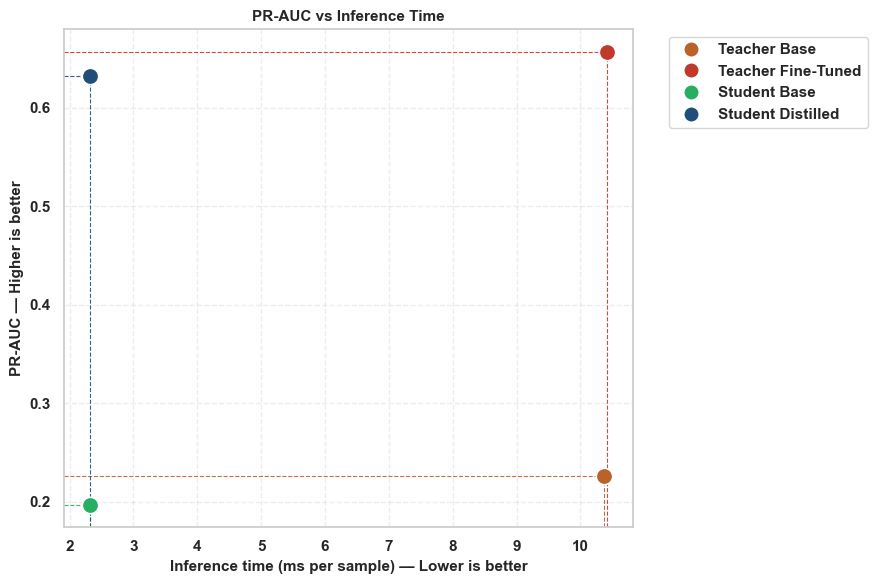

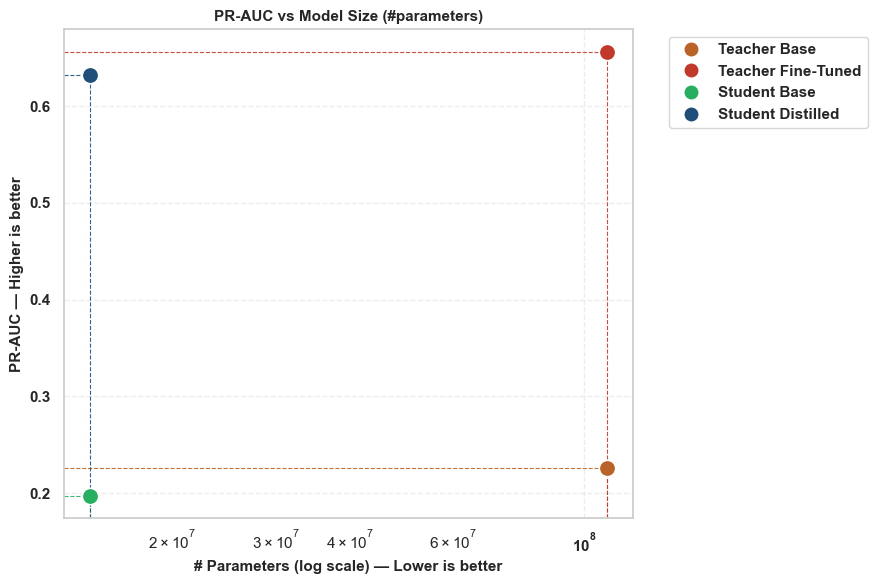

In [ ]:
fig1, ax1 = plot_scatter_prauc_vs_time(df_eff, title="PR-AUC vs Inference Time")
plt.show()
fig1.savefig(FIG_DIR / "scatter_time_auc.png", dpi=600)


fig2, ax2 = plot_scatter_prauc_vs_params(df_eff, title="PR-AUC vs Model Size (#parameters)")
plt.show()
fig2.savefig(FIG_DIR / "scatter_params_auc.png", dpi=600)


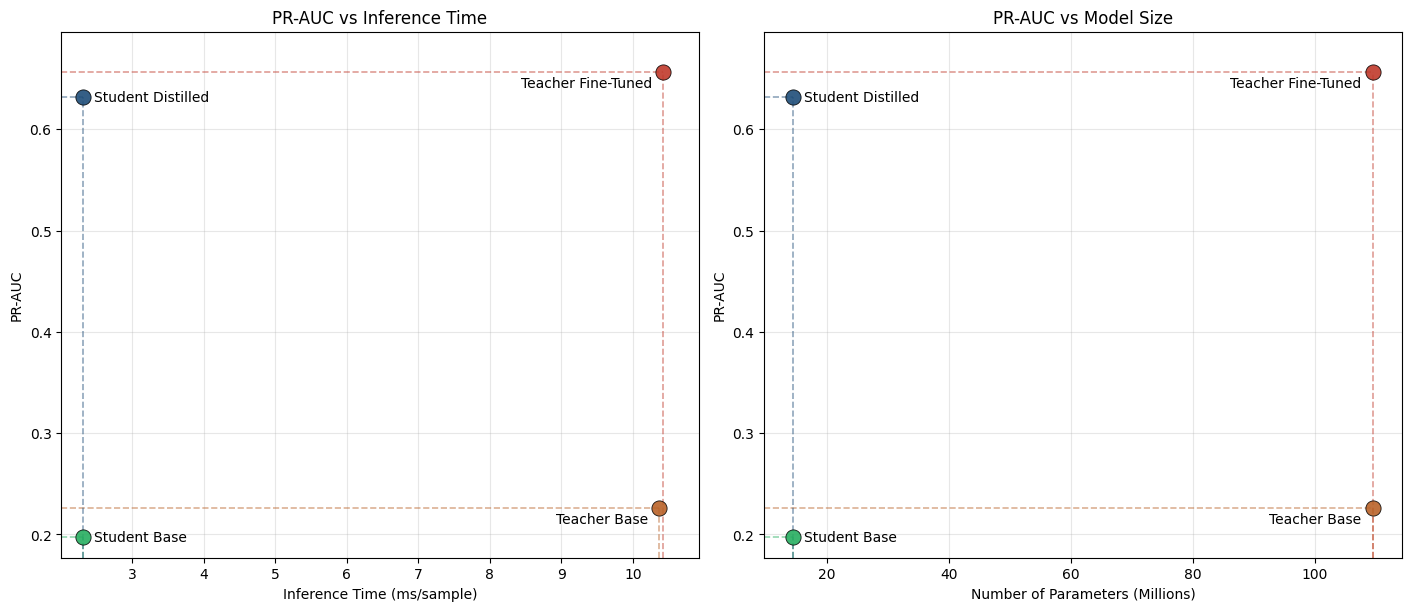

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_eff = pd.DataFrame([
    {
        "ModelKey": "teacher_base",
        "Model": "Teacher Base",
        "PR-AUC": 0.226396,
        "ROC-AUC": 0.433881,
        "F1": 0.411139,
        "ms_per_sample": 10.369329,
        "samples_per_second": 96.438259,
        "n_params": 109482240,
        "color": "#b96329",
    },
    {
        "ModelKey": "teacher_ft",
        "Model": "Teacher Fine-Tuned",
        "PR-AUC": 0.656376,
        "ROC-AUC": 0.818076,
        "F1": 0.596423,
        "ms_per_sample": 10.420548,
        "samples_per_second": 95.964244,
        "n_params": 109482240,
        "color": "#c0392b",
    },
    {
        "ModelKey": "student_base",
        "Model": "Student Base",
        "PR-AUC": 0.197066,
        "ROC-AUC": 0.364079,
        "F1": 0.412198,
        "ms_per_sample": 2.316629,
        "samples_per_second": 431.661744,
        "n_params": 14500000,
        "color": "#27ae60",
    },
    {
        "ModelKey": "student_kd",
        "Model": "Student Distilled",
        "PR-AUC": 0.631799,
        "ROC-AUC": 0.803560,
        "F1": 0.573548,
        "ms_per_sample": 2.312694,
        "samples_per_second": 432.396100,
        "n_params": 14500000,
        "color": "#1f4e79",
    },
])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

ymin = df_eff["PR-AUC"].min() - 0.02
ymax = df_eff["PR-AUC"].max() + 0.04

xmin_time = df_eff["ms_per_sample"].min() - 0.3
xmax_time = df_eff["ms_per_sample"].max() + 0.5

xmin_params = (df_eff["n_params"].min() / 1e6) - 0.05 * ((df_eff["n_params"].max() - df_eff["n_params"].min()) / 1e6)
xmax_params = (df_eff["n_params"].max() / 1e6) + 0.05 * ((df_eff["n_params"].max() - df_eff["n_params"].min()) / 1e6)

def annotate_by_model(ax, x, y, label, model_key):
    if "teacher" in model_key:
        ax.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=(-8, -8),
            ha="right",
            va="center",
            fontsize=10,
        )
    else:
        ax.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=(8, 0),
            ha="left",
            va="center",
            fontsize=10,
        )

ax = axes[0]
for _, row in df_eff.iterrows():
    ax.vlines(
        x=row["ms_per_sample"],
        ymin=ymin,
        ymax=row["PR-AUC"],
        colors=row["color"],
        linestyles="dashed",
        alpha=0.5,
        linewidth=1.2,
    )
    ax.hlines(
        y=row["PR-AUC"],
        xmin=xmin_time,
        xmax=row["ms_per_sample"],
        colors=row["color"],
        linestyles="dashed",
        alpha=0.5,
        linewidth=1.2,
    )
    ax.scatter(
        row["ms_per_sample"],
        row["PR-AUC"],
        s=120,
        color=row["color"],
        alpha=0.9,
        edgecolors="black",
        linewidths=0.6,
        zorder=3,
    )
    annotate_by_model(ax, row["ms_per_sample"], row["PR-AUC"], row["Model"], row["ModelKey"])

ax.set_title("PR-AUC vs Inference Time")
ax.set_xlabel("Inference Time (ms/sample)")
ax.set_ylabel("PR-AUC")
ax.set_xlim(xmin_time, xmax_time)
ax.set_ylim(ymin, ymax)
ax.grid(True, alpha=0.3)

ax = axes[1]
for _, row in df_eff.iterrows():
    ax.vlines(
        x=row["n_params"] / 1e6,
        ymin=ymin,
        ymax=row["PR-AUC"],
        colors=row["color"],
        linestyles="dashed",
        alpha=0.5,
        linewidth=1.2,
    )
    ax.hlines(
        y=row["PR-AUC"],
        xmin=xmin_params,
        xmax=row["n_params"]/ 1e6,
        colors=row["color"],
        linestyles="dashed",
        alpha=0.5,
        linewidth=1.2,
    )
    ax.scatter(
        row["n_params"]/ 1e6,
        row["PR-AUC"],
        s=120,
        color=row["color"],
        alpha=0.9,
        edgecolors="black",
        linewidths=0.6,
        zorder=3,
    )
    annotate_by_model(ax, row["n_params"]/ 1e6, row["PR-AUC"], row["Model"], row["ModelKey"])

ax.set_title("PR-AUC vs Model Size")
ax.set_xlabel("Number of Parameters (Millions)")
ax.set_ylabel("PR-AUC")
ax.set_xlim(xmin_params, xmax_params)
ax.set_ylim(ymin, ymax)
ax.grid(True, alpha=0.3)

plt.show()

fig.savefig(FIG_DIR / "efficiency_tradeoff.png", dpi=1000, bbox_inches="tight")